# 🔐 Exploring Encrypted Bitcoin Data – A Walkthrough

This notebook provides a step‑by‑step exploration of the encrypted dataset produced by a **row‑level indexed CKKS homomorphic encryption** scheme.

## 📁 Files in this directory
```
BTC_DATA_he_index.csv      # Index table – human‑readable structure, placeholders for sensitive columns
cipher_store.jsonl         # Actual encrypted data, one row per ciphertext vector
feature_manifest.json      # Metadata about columns, encryption scheme, and parameters
scaler_params.csv          # Preprocessing parameters (median, mean, std) for each encrypted feature
public_context.bin         # Public encryption context – can be shared for computations
secret_context.bin         # Private decryption context – keep safe!
```

### 🧠 High‑level idea
- The **index table** keeps the original row order, non‑sensitive columns in plaintext, and replaces sensitive columns with a placeholder (`[HE_ENCRYPTED]`). A new column `he_row_id` links each row to its corresponding ciphertext.
- The **cipher store** (JSONL) holds the actual homomorphic ciphertexts, one per row, as base64‑encoded strings. These can be used for privacy‑preserving computations.
- The **manifest** and **scaler parameters** describe how the data was preprocessed and encrypted.
- The **public context** allows further homomorphic operations (e.g., inference) without exposing the private key.

Let’s dive in!

## 1. Setup and Imports
We’ll need the following libraries:

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 2. Load and Understand the Feature Manifest
The `feature_manifest.json` contains the blueprint of the dataset.

In [2]:
manifest_path = Path("feature_manifest.json")
with open(manifest_path, "r") as f:
    manifest = json.load(f)

# Display the main entries
print("=== Encryption scheme ===")
print(f"Scheme: {manifest['scheme']}")
print(f"Library: {manifest['library']}")
print(f"Index mode: {manifest['index_mode']}")
print(f"Number of rows: {manifest['rows']}")
print(f"Polynomial modulus degree: {manifest['poly_modulus_degree']}")
print(f"Global scale: {manifest['global_scale']}")

=== Encryption scheme ===
Scheme: CKKS
Library: TenSEAL
Index mode: row_level_reference
Number of rows: 4389
Polynomial modulus degree: 8192
Global scale: 1099511627776


The manifest tells us:
- The encryption scheme is **CKKS** (ideal for real numbers).
- The library used is **TenSEAL**.
- We have **4389** rows of data.
- The CKKS parameters (`poly_modulus_degree`, `coeff_mod_bit_sizes`) determine the security and precision.

In [3]:
# Let's look at the columns
print("\n=== Total number of columns in original data ===")
print(f"{len(manifest['columns'])} columns")

# Which columns are actually encrypted?
print("\n=== Encrypted feature columns ===")
encrypted_features = manifest['encrypted_features']
print(f"{len(encrypted_features)} columns:")
print(encrypted_features)

# The rest of the columns (non‑encrypted) are stored in plaintext in the index table.
non_encrypted = [c for c in manifest['columns'] if c not in encrypted_features]
print(f"\n=== Non‑encrypted columns (stored in plaintext) ===")
print(f"{len(non_encrypted)} columns (first 20 shown):")
print(non_encrypted[:20])


=== Total number of columns in original data ===
738 columns

=== Encrypted feature columns ===
16 columns:
['priceUSD', 'transactions', 'size', 'sentbyaddress', 'difficulty', 'hashrate', 'mining_profitability', 'sentinusdUSD', 'transactionfeesUSD', 'median_transaction_feeUSD', 'confirmationtime', 'transactionvalueUSD', 'mediantransactionvalueUSD', 'activeaddresses', 'top100cap', 'fee_to_rewardUSD']

=== Non‑encrypted columns (stored in plaintext) ===
722 columns (first 20 shown):
['Unnamed: 0', 'Date', 'transactions3sma', 'transactions7sma', 'transactions14sma', 'transactions30sma', 'transactions90sma', 'transactions3ema', 'transactions7ema', 'transactions14ema', 'transactions30ema', 'transactions90ema', 'transactions3wma', 'transactions7wma', 'transactions14wma', 'transactions30wma', 'transactions90wma', 'transactions3trx', 'transactions7trx', 'transactions14trx']


**Interpretation:**  
The original dataset contains many time‑series derived features (moving averages, momentum, etc.). Only a core set of base features (like `priceUSD`, `transactions`, `size`, etc.) are encrypted. This means the index table is still very informative for exploratory analysis.

## 3. Load the Index Table (`BTC_DATA_he_index.csv`)
This is the human‑readable version of the data.

In [4]:
index_path = Path("BTC_DATA_he_index.csv")
df_index = pd.read_csv(index_path)

print(f"Shape: {df_index.shape[0]} rows × {df_index.shape[1]} columns")
print("\nFirst 5 rows:")
df_index.head()

Shape: 4389 rows × 739 columns

First 5 rows:


,Unnamed: 0,Date,priceUSD,transactions,size,sentbyaddress,difficulty,hashrate,mining_profitability,sentinusdUSD,...,price7rsiUSD,price14rsiUSD,price30rsiUSD,price90rsiUSD,price3rocUSD,price7rocUSD,price14rocUSD,price30rocUSD,price90rocUSD,he_row_id
0,0,2010/07/18,[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],...,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,row_000000
1,1,2010/07/19,[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],...,0.0,0.0,0.0,0.0,0.000,0.0,0.0,0.0,0.0,row_000001
2,2,2010/07/20,[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],...,0.0,0.0,0.0,0.0,58.099,0.0,0.0,0.0,0.0,row_000002
3,3,2010/07/21,[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],...,0.0,0.0,0.0,0.0,5.652,0.0,0.0,0.0,0.0,row_000003
4,4,2010/07/22,[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],[HE_ENCRYPTED],...,0.0,0.0,0.0,0.0,-24.455,0.0,0.0,0.0,0.0,row_000004


The index table contains:
- **All original columns** (including the derived ones) in plaintext.
- **Sensitive columns** (the ones listed in `encrypted_features`) are replaced by the placeholder `[HE_ENCRYPTED]`.
- A new column **`he_row_id`** – a unique identifier that links to the cipher store.

In [5]:
# Check the placeholder values
sensitive_cols_present = [col for col in encrypted_features if col in df_index.columns]
print("Sensitive columns in index table:")
print(sensitive_cols_present)
print("\nExample values in the first row for those columns:")
print(df_index.loc[0, sensitive_cols_present].values)

Sensitive columns in index table:
['priceUSD', 'transactions', 'size', 'sentbyaddress', 'difficulty', 'hashrate', 'mining_profitability', 'sentinusdUSD', 'transactionfeesUSD', 'median_transaction_feeUSD', 'confirmationtime', 'transactionvalueUSD', 'mediantransactionvalueUSD', 'activeaddresses', 'top100cap', 'fee_to_rewardUSD']

Example values in the first row for those columns:
['[HE_ENCRYPTED]' '[HE_ENCRYPTED]' '[HE_ENCRYPTED]' '[HE_ENCRYPTED]'
 '[HE_ENCRYPTED]' '[HE_ENCRYPTED]' '[HE_ENCRYPTED]' '[HE_ENCRYPTED]'
 '[HE_ENCRYPTED]' '[HE_ENCRYPTED]' '[HE_ENCRYPTED]' '[HE_ENCRYPTED]'
 '[HE_ENCRYPTED]' '[HE_ENCRYPTED]' '[HE_ENCRYPTED]' '[HE_ENCRYPTED]']


Indeed, each sensitive column shows the placeholder string.

In [6]:
# Show the `he_row_id` column
print("he_row_id values (first 10):")
print(df_index['he_row_id'].head(10).values)

he_row_id values (first 10):
['row_000000' 'row_000001' 'row_000002' 'row_000003' 'row_000004'
 'row_000005' 'row_000006' 'row_000007' 'row_000008' 'row_000009']


The `he_row_id` is a numeric (or string) identifier that will be used to retrieve the corresponding ciphertext from `cipher_store.jsonl`.

## 4. Explore Non‑Encrypted (Plaintext) Columns
Since most derived features are in plaintext, we can visualise them to understand the data context.

In [7]:
# List all non‑encrypted columns that actually exist in the index
non_encrypted_in_index = [c for c in non_encrypted if c in df_index.columns]
print(f"{len(non_encrypted_in_index)} non‑encrypted columns are present in the index table.")

722 non‑encrypted columns are present in the index table.


We can, for example, plot the `Date` column against some moving averages to see trends.

Date range: 2010-07-18 00:00:00 to 2022-07-23 00:00:00


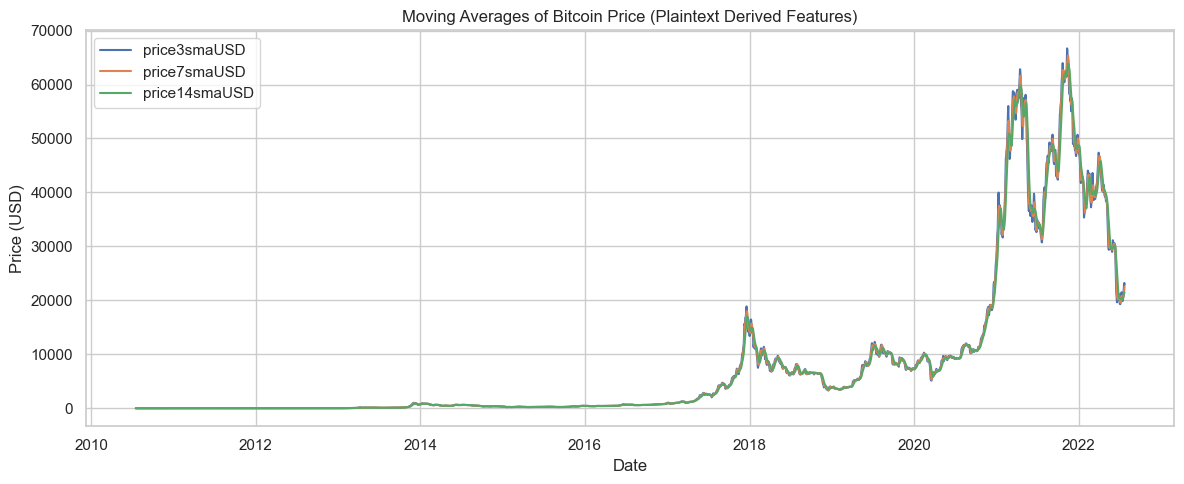

In [8]:
# Convert Date column to datetime if it exists
if 'Date' in df_index.columns:
    df_index['Date'] = pd.to_datetime(df_index['Date'])
    df_index = df_index.sort_values('Date')
    print(f"Date range: {df_index['Date'].min()} to {df_index['Date'].max()}")

# Plot priceUSD (non‑encrypted? Actually priceUSD is encrypted, so it will be placeholder – we cannot plot it directly.
# Instead, we can use one of the derived moving averages of price, e.g., price30smaUSD, which is not encrypted.
price_ma_cols = [c for c in non_encrypted_in_index if 'price' in c.lower() and 'sma' in c.lower()]
if price_ma_cols and 'Date' in df_index.columns:
    plt.figure(figsize=(12, 5))
    for col in price_ma_cols[:3]:  # limit to first 3 for clarity
        plt.plot(df_index['Date'], df_index[col], label=col)
    plt.title("Moving Averages of Bitcoin Price (Plaintext Derived Features)")
    plt.xlabel("Date")
    plt.ylabel("Price (USD)")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No price SMA columns found in non‑encrypted list, or 'Date' not available.")

Similarly, we can look at transaction volumes or other metrics.

Column 'activeaddresses' is not in the non‑encrypted list (maybe it is encrypted?). Actually it's in encrypted_features, so it's placeholder.

Some derived columns that are plaintext (first 10):
['transactions3sma', 'transactions7sma', 'transactions14sma', 'transactions30sma', 'transactions90sma', 'transactions3ema', 'transactions7ema', 'transactions14ema', 'transactions30ema', 'transactions90ema']


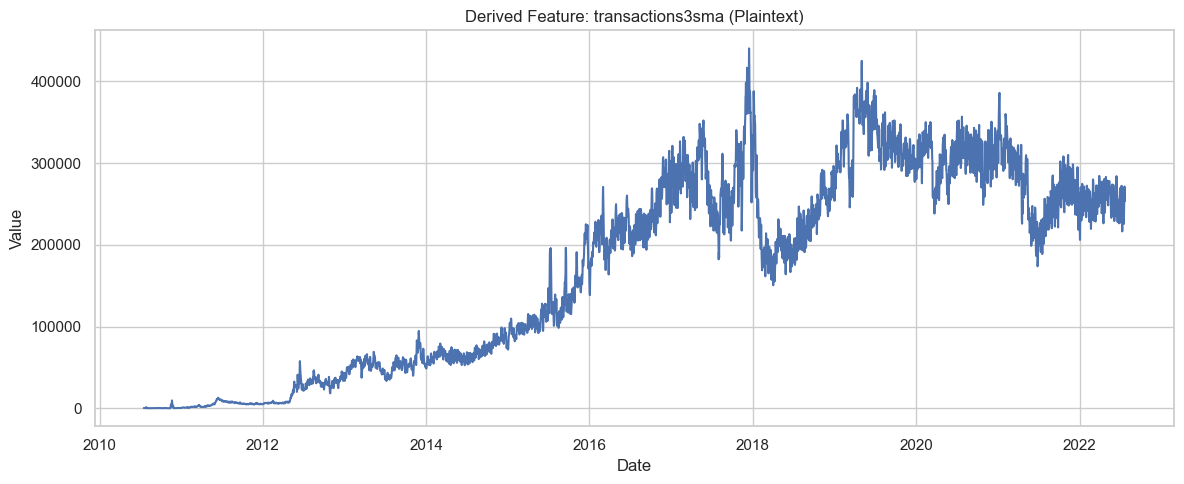

In [9]:
# For example, plot the number of active addresses (plaintext) over time
if 'activeaddresses' in non_encrypted_in_index and 'Date' in df_index.columns:
    plt.figure(figsize=(12, 5))
    plt.plot(df_index['Date'], df_index['activeaddresses'], label='Active Addresses', color='orange')
    plt.title("Active Bitcoin Addresses Over Time (Plaintext)")
    plt.xlabel("Date")
    plt.ylabel("Number of addresses")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'activeaddresses' is not in the non‑encrypted list (maybe it is encrypted?). Actually it's in encrypted_features, so it's placeholder.")

# Wait, activeaddresses is in encrypted_features, so it's not in plaintext. Let's pick something that is definitely non‑encrypted.
# According to the manifest, the non‑encrypted columns are the many derived columns. For example, `price30smaUSD` is derived and should be plaintext.
# Let's list a few examples:

print("\nSome derived columns that are plaintext (first 10):")
derived_examples = [c for c in non_encrypted_in_index if 'sma' in c or 'ema' in c or 'wma' in c][:10]
print(derived_examples)

# Plot one of them
if derived_examples and 'Date' in df_index.columns:
    col = derived_examples[0]
    plt.figure(figsize=(12, 5))
    plt.plot(df_index['Date'], df_index[col], label=col)
    plt.title(f"Derived Feature: {col} (Plaintext)")
    plt.xlabel("Date")
    plt.ylabel("Value")
    plt.tight_layout()
    plt.show()

This demonstrates that even though the core features are encrypted, we can still examine many derived metrics to understand the data landscape.

## 5. Load Preprocessing Parameters (`scaler_params.csv`)
Before encryption, the sensitive features were:
- Missing values filled with the median of the column.
- Standardized (z‑score) using mean and standard deviation.

The `scaler_params.csv` stores these values so that the same preprocessing can be applied to new data during inference, and so that decrypted results can be transformed back to the original scale.

In [10]:
scaler_path = Path("scaler_params.csv")
df_scaler = pd.read_csv(scaler_path)
print("Scaler parameters (first 5 rows):")
df_scaler.head()

Scaler parameters (first 5 rows):


,feature,fill_median,mean,std
0,priceUSD,6.624950e+02,8.197992e+03,1.459026e+04
1,transactions,1.962850e+05,1.709768e+05,1.211085e+05
2,size,6.033280e+05,5.103650e+05,3.416814e+05
3,sentbyaddress,2.927480e+05,2.600761e+05,1.899215e+05
4,difficulty,2.133989e+11,5.641314e+12,8.576982e+12


For each encrypted feature we have:
- `fill_median`: value used to replace missing entries.
- `mean`: mean of the cleaned column.
- `std`: standard deviation of the cleaned column.

## 6. Load the Cipher Store (`cipher_store.jsonl`)
This file contains the actual homomorphic ciphertexts. Each line is a JSON object.

In [12]:
cipher_path = Path("cipher_store.jsonl")
cipher_entries = []
with open(cipher_path, "r") as f:
    for line in f:
        cipher_entries.append(json.loads(line))

print(f"Total ciphertext entries: {len(cipher_entries)}")
print("\nFirst entry (keys only):")
print(cipher_entries[0].keys())

Total ciphertext entries: 4389

First entry (keys only):
dict_keys(['row_id', 'row_index', 'features', 'ciphertext_b64'])


Each entry has:
- `row_id`: corresponds to the `he_row_id` in the index table.
- `row_index`: original row number (0‑based).
- `features`: list of feature names (order matches the ciphertext vector).
- `ciphertext_b64`: base64‑encoded serialized ciphertext.

In [13]:
# Show a sample entry (without printing the huge base64 string)
sample = cipher_entries[0]
print(f"row_id: {sample['row_id']}")
print(f"row_index: {sample['row_index']}")
print(f"features: {sample['features']}")
print(f"ciphertext_b64 length: {len(sample['ciphertext_b64'])} characters")

row_id: row_000000
row_index: 0
features: ['priceUSD', 'transactions', 'size', 'sentbyaddress', 'difficulty', 'hashrate', 'mining_profitability', 'sentinusdUSD', 'transactionfeesUSD', 'median_transaction_feeUSD', 'confirmationtime', 'transactionvalueUSD', 'mediantransactionvalueUSD', 'activeaddresses', 'top100cap', 'fee_to_rewardUSD']
ciphertext_b64 length: 445608 characters


The `features` list should match the `encrypted_features` from the manifest, in the same order.

In [14]:
# Verify the feature order matches
if sample['features'] == encrypted_features:
    print("✓ Feature order matches manifest.")
else:
    print("Feature order differs! Check manifest or cipher store.")

✓ Feature order matches manifest.


## 7. Link Index Table to Cipher Store
To retrieve the ciphertext for a specific row, we use `he_row_id`.

In [15]:
# Get a sample row from the index table
sample_row = df_index.iloc[0]
row_id = sample_row['he_row_id']
print(f"Row 0 has he_row_id = {row_id}")

# Find the corresponding entry in cipher_entries
cipher_match = [e for e in cipher_entries if e['row_id'] == row_id]
if cipher_match:
    print("Found matching ciphertext entry.")
    # The actual ciphertext is in cipher_match[0]['ciphertext_b64'] – we could load it into TenSEAL if needed.
else:
    print("No matching ciphertext found! Something is inconsistent.")

Row 0 has he_row_id = row_000000
Found matching ciphertext entry.


This linking mechanism allows us to:
- Keep the index table clean and human‑readable.
- Store the bulky ciphertexts separately.
- Easily retrieve the encrypted data for any row when performing homomorphic computations.

## 8. What Can We Do Next?

- **Homomorphic inference:** Load `public_context.bin` and the ciphertexts into TenSEAL, then run machine learning models (e.g., linear regression, logistic regression) on the encrypted data without ever decrypting it.
- **Decryption (authorised only):** With `secret_context.bin` and the ciphertext, one can decrypt and recover the original values (after reversing the scaling).
- **Data integration:** The index table can be used by dashboards or agents that need the structure but not the raw sensitive numbers.

### Example (pseudo‑code) of loading a ciphertext:
```python
import tenseal as ts
context = ts.Context.load("public_context.bin")
ciphertext = ts.ckks_vector_from(context, sample_cipher_b64)  # after base64 decoding
```
But note: without the secret key, you cannot decrypt it – that's the point of homomorphic encryption.

## 9. Conclusion

This dataset is organised in a way that balances:
- **Privacy:** Sensitive columns are homomorphically encrypted.
- **Usability:** Plaintext derived columns and the index table allow exploration without decryption.
- **Flexibility:** The cipher store and public context enable secure computations.

The provided files give you everything you need to work with the data, whether you are a data scientist exploring trends, a developer building a privacy‑preserving inference service, or a security auditor verifying the encryption setup.

**Next steps:** Try loading the public context and ciphertexts into TenSEAL, then experiment with homomorphic operations (addition, multiplication, dot products) to see how the encryption works under the hood.